In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load and prepare data
data = pd.read_csv("/content/ner_dataset.csv", encoding="latin1").ffill()
words = list(data["Word"].unique())
tags = list(data["Tag"].unique())

if "ENDPAD" not in words:
    words.append("ENDPAD")

# Add a special padding tag to the list of tags
if "PAD_TAG" not in tags:
    tags.append("PAD_TAG")

word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}

In [4]:
data.head(50)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


In [5]:
print("Unique words in corpus:", data['Word'].nunique())
print("Unique tags in corpus:", data['Tag'].nunique())

Unique words in corpus: 9563
Unique tags in corpus: 17


In [6]:
print("Unique tags are:", tags)

Unique tags are: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat', 'PAD_TAG']


In [7]:
# Group words by sentences
class SentenceGetter:
    def __init__(self, data):
        self.grouped = data.groupby("Sentence #", group_keys=False).apply(
            lambda s: [(w, t) for w, t in zip(s["Word"], s["Tag"])]
        )
        self.sentences = list(self.grouped)

getter = SentenceGetter(data)
sentences = getter.sentences

In [8]:
sentences[35]

[('On', 'O'),
 ('Friday', 'B-tim'),
 (',', 'O'),
 ('five', 'O'),
 ('soldiers', 'O'),
 ('were', 'O'),
 ('killed', 'O'),
 ('when', 'O'),
 ('dozens', 'O'),
 ('of', 'O'),
 ('militants', 'O'),
 ('stormed', 'O'),
 ('a', 'O'),
 ('military', 'O'),
 ('checkpoint', 'O'),
 ('in', 'O'),
 ('Orakzai', 'B-geo'),
 ('.', 'O')]

In [9]:
# Encode sentences
X = [[word2idx[w] for w, t in s] for s in sentences]
y = [[tag2idx[t] for w, t in s] for s in sentences]

In [10]:
word2idx

{'Thousands': 1,
 'of': 2,
 'demonstrators': 3,
 'have': 4,
 'marched': 5,
 'through': 6,
 'London': 7,
 'to': 8,
 'protest': 9,
 'the': 10,
 'war': 11,
 'in': 12,
 'Iraq': 13,
 'and': 14,
 'demand': 15,
 'withdrawal': 16,
 'British': 17,
 'troops': 18,
 'from': 19,
 'that': 20,
 'country': 21,
 '.': 22,
 'Families': 23,
 'soldiers': 24,
 'killed': 25,
 'conflict': 26,
 'joined': 27,
 'protesters': 28,
 'who': 29,
 'carried': 30,
 'banners': 31,
 'with': 32,
 'such': 33,
 'slogans': 34,
 'as': 35,
 '"': 36,
 'Bush': 37,
 'Number': 38,
 'One': 39,
 'Terrorist': 40,
 'Stop': 41,
 'Bombings': 42,
 'They': 43,
 'Houses': 44,
 'Parliament': 45,
 'a': 46,
 'rally': 47,
 'Hyde': 48,
 'Park': 49,
 'Police': 50,
 'put': 51,
 'number': 52,
 'marchers': 53,
 'at': 54,
 '10,000': 55,
 'while': 56,
 'organizers': 57,
 'claimed': 58,
 'it': 59,
 'was': 60,
 '1,00,000': 61,
 'The': 62,
 'comes': 63,
 'on': 64,
 'eve': 65,
 'annual': 66,
 'conference': 67,
 'Britain': 68,
 "'s": 69,
 'ruling': 70,
 'L

In [11]:
# Pad sequences
max_len = 50
X_pad = pad_sequence([torch.tensor(seq) for seq in X], batch_first=True, padding_value=word2idx["ENDPAD"])
y_pad = pad_sequence([torch.tensor(seq) for seq in y], batch_first=True, padding_value=tag2idx["PAD_TAG"])
X_pad = X_pad[:, :max_len]
y_pad = y_pad[:, :max_len]

In [12]:
X_pad[0]

tensor([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,   12,
          13,   14,   15,   10,   16,    2,   17,   18,   19,   20,   21,   22,
        9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564,
        9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564, 9564,
        9564, 9564])

In [13]:
y_pad[0]

tensor([ 0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,
         2,  0,  0,  0,  0,  0, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
        17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17])

In [14]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=1)

In [15]:
# Dataset class
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "labels": self.y[idx]
        }

train_loader = DataLoader(NERDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(NERDataset(X_test, y_test), batch_size=32)

In [16]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=100, hidden_dim=256, dropout=0.5):
        super(BiLSTMTagger, self).__init__()
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.hidden2tag = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, input_ids):
        embeddings = self.word_embeddings(input_ids)
        embeddings = self.dropout(embeddings)
        lstm_out, _ = self.lstm(embeddings)
        lstm_out = self.dropout(lstm_out)
        tag_space = self.hidden2tag(lstm_out)
        return tag_space

In [17]:
model = BiLSTMTagger(len(words) + 1, len(tags)).to(device)
# Use PAD_TAG for ignore_index in CrossEntropyLoss
loss_fn = nn.CrossEntropyLoss(ignore_index=tag2idx["PAD_TAG"])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
# Training and Evaluation Functions
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=10):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
      model.train()
      total_loss = 0
      for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = loss_fn(outputs.view(-1, len(tag2idx)), labels.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
      train_losses.append(total_loss)

      model.eval()
      val_loss = 0
      with torch.no_grad():
        for batch in test_loader:
          input_ids = batch["input_ids"].to(device)
          labels = batch['labels'].to(device)
          outputs = model(input_ids)
          loss = loss_fn(outputs.view(-1, len(tag2idx)), labels.view(-1))
          val_loss += loss.item()
      val_losses.append(val_loss)
      print(f"Epoch {epoch+1}: Train Loss = {total_loss:.4f}, Val Loss = {val_loss:.4f}")

    return train_losses, val_losses

In [19]:
# Training and Evaluation Functions
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=10):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
      model.train()
      total_loss = 0
      for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = loss_fn(outputs.view(-1, len(tag2idx)), labels.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
      train_losses.append(total_loss)

      model.eval()
      val_loss = 0
      with torch.no_grad():
        for batch in test_loader:
          input_ids = batch["input_ids"].to(device)
          labels = batch['labels'].to(device)
          outputs = model(input_ids)
          loss = loss_fn(outputs.view(-1, len(tag2idx)), labels.view(-1))
          val_loss += loss.item()
      val_losses.append(val_loss)
      print(f"Epoch {epoch+1}: Train Loss = {total_loss:.4f}, Val Loss = {val_loss:.4f}")

    return train_losses, val_losses

def evaluate_model(model, test_loader, X_test, y_test):
    model.eval()
    true_tags, pred_tags = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=-1)
            for i in range(len(labels)):
                for j in range(len(labels[i])):
                    # Only consider non-padding tokens for evaluation (excluding PAD_TAG)
                    if labels[i][j].item() != tag2idx["PAD_TAG"]:
                        true_tags.append(idx2tag[labels[i][j].item()])
                        pred_tags.append(idx2tag[preds[i][j].item()])
    print(classification_report(true_tags, pred_tags, zero_division=0))

In [20]:
# Run training and evaluation
train_losses, val_losses = train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=10)
evaluate_model(model, test_loader, X_test, y_test)

Epoch 1: Train Loss = 80.4374, Val Loss = 14.9851
Epoch 2: Train Loss = 54.9620, Val Loss = 11.9603
Epoch 3: Train Loss = 46.5416, Val Loss = 10.2483
Epoch 4: Train Loss = 40.5259, Val Loss = 8.9979
Epoch 5: Train Loss = 36.6324, Val Loss = 8.3762
Epoch 6: Train Loss = 33.5732, Val Loss = 7.6300
Epoch 7: Train Loss = 31.0593, Val Loss = 7.2904
Epoch 8: Train Loss = 28.8779, Val Loss = 7.0073
Epoch 9: Train Loss = 27.0836, Val Loss = 6.5655
Epoch 10: Train Loss = 25.0809, Val Loss = 6.3415
              precision    recall  f1-score   support

       B-art       0.00      0.00      0.00        13
       B-eve       0.00      0.00      0.00        14
       B-geo       0.68      0.73      0.71       496
       B-gpe       0.84      0.58      0.69       242
       B-nat       0.00      0.00      0.00         8
       B-org       0.70      0.32      0.44       266
       B-per       0.76      0.47      0.58       281
       B-tim       0.87      0.66      0.75       292
       I-art       

Name: SUBHASH V
Reg. no.: 212224240163


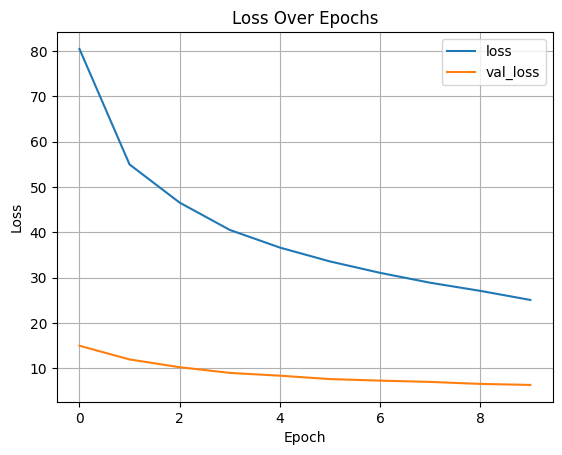

In [21]:
# Plot loss
print('Name: SUBHASH V')
print('Reg. no.: 212224240163')
history_df = pd.DataFrame({"loss": train_losses, "val_loss": val_losses})
history_df.plot(title="Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [22]:
# Inference and prediction
i = 125
model.eval()
sample = X_test[i].unsqueeze(0).to(device)
output = model(sample)
preds = torch.argmax(output, dim=-1).squeeze().cpu().numpy()
true = y_test[i].numpy()

print('Name: SUBHASH V')
print('Reg. no.: 212224240163')
print("{:<15} {:<10} {}\n{}".format("Word", "True", "Pred", "-" * 40))
for w_id, true_tag, pred_tag in zip(X_test[i], y_test[i], preds):
    if w_id.item() != word2idx["ENDPAD"]:
        word = words[w_id.item() - 1]
        true_label = tags[true_tag.item()]
        pred_label = tags[pred_tag]
        print(f"{word:<15} {true_label:<10} {pred_label}")

Name: SUBHASH V
Reg. no.: 212224240163
Word            True       Pred
----------------------------------------
A               O          O
total           O          O
of              O          O
25              O          O
were            O          O
tried           O          O
in              O          O
absentia        O          O
,               O          O
while           O          O
14              O          O
others          O          O
have            O          O
died            O          O
since           O          O
the             O          O
trial           O          O
began           O          O
in              O          O
1994            B-tim      B-geo
.               O          O
